In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [2]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target

<Axes: >

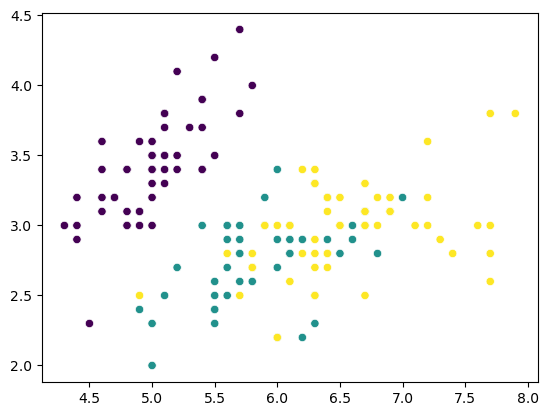

In [5]:
sns.scatterplot(x = X[:,0] , y = X[:,1] , c = y)

In [6]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Dimentionality Reduction
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)

In [24]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state = 11)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)

C:\Users\hacke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hacke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hacke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hacke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [25]:
# Value of K 
from kneed import KneeLocator
knee = KneeLocator(range(1,11),wcss,curve = "convex",direction = "decreasing")

In [26]:
# Model 
kmeans = KMeans(n_clusters = knee.knee,random_state = 11)
labels = kmeans.fit_predict(pca_data)

C:\Users\hacke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

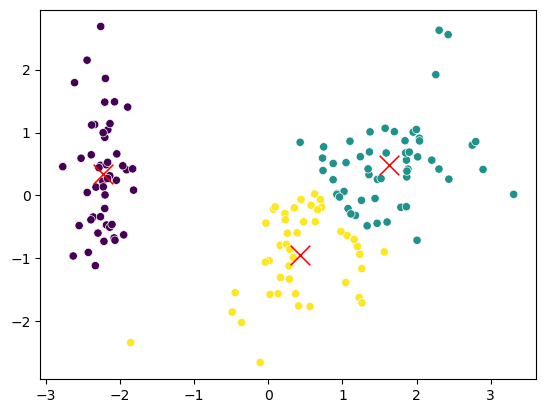

In [33]:
sns.scatterplot(x = pca_data[:,0], y = pca_data[:,1] , c = labels)
sns.scatterplot(x = kmeans.cluster_centers_[:,0], y =kmeans.cluster_centers_[:,1],marker = "x",s=200,c="red")